# 📊 Exploration naïve des données

---
## 1. Chargement des données

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ Numpy version: {np.__version__}")

✅ Pandas version: 2.3.1
✅ Numpy version: 2.3.1


In [2]:
# Chemins des fichiers
DATA_PATH = Path('../data/raw')
FAO_FILE = DATA_PATH / 'FAO.csv'
IMPACT_FILE = DATA_PATH / 'Food_Production.csv'

print(f"📂 Dossier données: {DATA_PATH.absolute()}")
print(f"✅ FAO.csv existe: {FAO_FILE.exists()}")
print(f"✅ Food_Production.csv existe: {IMPACT_FILE.exists()}")

📂 Dossier données: c:\Users\Emeline\Documents\_DEV\_Projets_Jedha\_impact_envt_project\notebooks\..\data\raw
✅ FAO.csv existe: True
✅ Food_Production.csv existe: True


---
## 2. Analyse FAO.csv - Production mondiale

### 2.1 Chargement et inspection initiale

In [3]:
# Chargement FAO (peut prendre quelques secondes pour 4.4 MB)
print("⏳ Chargement FAO.csv...")

# Le fichier FAO.csv n'est pas en UTF-8, on essaie différents encodages
try:
    df_fao = pd.read_csv(FAO_FILE, encoding='latin-1')
    print("✅ Encodage détecté: latin-1")
except:
    try:
        df_fao = pd.read_csv(FAO_FILE, encoding='ISO-8859-1')
        print("✅ Encodage détecté: ISO-8859-1")
    except:
        df_fao = pd.read_csv(FAO_FILE, encoding='cp1252')
        print("✅ Encodage détecté: cp1252")

print(f"✅ Chargé: {len(df_fao):,} lignes × {len(df_fao.columns)} colonnes")

# Aperçu
df_fao.head()

⏳ Chargement FAO.csv...
✅ Encodage détecté: latin-1
✅ Chargé: 21,477 lignes × 63 colonnes


,Area Abbreviation,Area Code,Area,Item Code,Item,Element Code,Element,Unit,latitude,longitude,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,Y1969,Y1970,Y1971,Y1972,Y1973,Y1974,Y1975,Y1976,Y1977,Y1978,Y1979,Y1980,Y1981,Y1982,Y1983,Y1984,Y1985,Y1986,Y1987,Y1988,Y1989,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,Y1998,Y1999,Y2000,Y2001,Y2002,Y2003,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
0,AFG,2,Afghanistan,2511,Wheat and products,5142,Food,1000 tonnes,33.94,67.71,1928.0,1904.0,1666.0,1950.0,2001.0,1808.0,2053.0,2045.0,2154.0,1819.0,1963.0,2215.0,2310.0,2335.0,2434.0,2512.0,2282.0,2454.0,2443.0,2129.0,2133.0,2068.0,1994.0,1851.0,1791.0,1683.0,2194.0,1801.0,1754.0,1640.0,1539.0,1582.0,1840.0,1855.0,1853.0,2177.0,2343.0,2407.0,2463.0,2600.0,2668.0,2776.0,3095.0,3249.0,3486.0,3704.0,4164.0,4252.0,4538.0,4605.0,4711.0,4810,4895
1,AFG,2,Afghanistan,2805,Rice (Milled Equivalent),5142,Food,1000 tonnes,33.94,67.71,183.0,183.0,182.0,220.0,220.0,195.0,231.0,235.0,238.0,213.0,205.0,233.0,246.0,246.0,255.0,263.0,235.0,254.0,270.0,259.0,248.0,217.0,217.0,197.0,186.0,200.0,193.0,202.0,191.0,199.0,197.0,249.0,218.0,260.0,319.0,254.0,326.0,347.0,270.0,372.0,411.0,448.0,460.0,419.0,445.0,546.0,455.0,490.0,415.0,442.0,476.0,425,422
2,AFG,2,Afghanistan,2513,Barley and products,5521,Feed,1000 tonnes,33.94,67.71,76.0,76.0,76.0,76.0,76.0,75.0,71.0,72.0,73.0,74.0,71.0,70.0,72.0,76.0,77.0,80.0,60.0,65.0,64.0,64.0,60.0,55.0,53.0,51.0,48.0,46.0,46.0,47.0,46.0,43.0,43.0,40.0,50.0,46.0,41.0,44.0,50.0,48.0,43.0,26.0,29.0,70.0,48.0,58.0,236.0,262.0,263.0,230.0,379.0,315.0,203.0,367,360
3,AFG,2,Afghanistan,2513,Barley and products,5142,Food,1000 tonnes,33.94,67.71,237.0,237.0,237.0,238.0,238.0,237.0,225.0,227.0,230.0,234.0,223.0,219.0,225.0,240.0,244.0,255.0,185.0,203.0,198.0,202.0,189.0,174.0,167.0,160.0,151.0,145.0,145.0,148.0,145.0,135.0,132.0,120.0,155.0,143.0,125.0,138.0,159.0,154.0,141.0,84.0,83.0,122.0,144.0,185.0,43.0,44.0,48.0,62.0,55.0,60.0,72.0,78,89
4,AFG,2,Afghanistan,2514,Maize and products,5521,Feed,1000 tonnes,33.94,67.71,210.0,210.0,214.0,216.0,216.0,216.0,235.0,232.0,236.0,200.0,201.0,216.0,228.0,231.0,234.0,240.0,228.0,234.0,228.0,226.0,210.0,199.0,192.0,182.0,173.0,170.0,154.0,148.0,137.0,144.0,126.0,90.0,141.0,150.0,159.0,108.0,90.0,99.0,72.0,35.0,48.0,89.0,63.0,120.0,208.0,233.0,249.0,247.0,195.0,178.0,191.0,200,200


### 2.2 Informations générales

In [4]:
# Dimensions
print("=" * 60)
print("📊 DIMENSIONS & STRUCTURE")
print("=" * 60)
print(f"Nombre de lignes (observations): {len(df_fao):,}")
print(f"Nombre de colonnes (variables): {len(df_fao.columns)}")
print(f"\nListe des colonnes:")
for i, col in enumerate(df_fao.columns, 1):
    print(f"  {i:2d}. {col}")

📊 DIMENSIONS & STRUCTURE
Nombre de lignes (observations): 21,477
Nombre de colonnes (variables): 63

Liste des colonnes:
   1. Area Abbreviation
   2. Area Code
   3. Area
   4. Item Code
   5. Item
   6. Element Code
   7. Element
   8. Unit
   9. latitude
  10. longitude
  11. Y1961
  12. Y1962
  13. Y1963
  14. Y1964
  15. Y1965
  16. Y1966
  17. Y1967
  18. Y1968
  19. Y1969
  20. Y1970
  21. Y1971
  22. Y1972
  23. Y1973
  24. Y1974
  25. Y1975
  26. Y1976
  27. Y1977
  28. Y1978
  29. Y1979
  30. Y1980
  31. Y1981
  32. Y1982
  33. Y1983
  34. Y1984
  35. Y1985
  36. Y1986
  37. Y1987
  38. Y1988
  39. Y1989
  40. Y1990
  41. Y1991
  42. Y1992
  43. Y1993
  44. Y1994
  45. Y1995
  46. Y1996
  47. Y1997
  48. Y1998
  49. Y1999
  50. Y2000
  51. Y2001
  52. Y2002
  53. Y2003
  54. Y2004
  55. Y2005
  56. Y2006
  57. Y2007
  58. Y2008
  59. Y2009
  60. Y2010
  61. Y2011
  62. Y2012
  63. Y2013


In [5]:
# Types de données
print("\n" + "=" * 60)
print("📋 TYPES DE DONNÉES")
print("=" * 60)
print(df_fao.dtypes.value_counts())
print("\nDétail:")
print(df_fao.dtypes)


📋 TYPES DE DONNÉES
float64    53
object      5
int64       5
Name: count, dtype: int64

Détail:
Area Abbreviation     object
Area Code              int64
Area                  object
Item Code              int64
Item                  object
Element Code           int64
Element               object
Unit                  object
latitude             float64
longitude            float64
Y1961                float64
Y1962                float64
Y1963                float64
Y1964                float64
Y1965                float64
Y1966                float64
Y1967                float64
Y1968                float64
Y1969                float64
Y1970                float64
Y1971                float64
Y1972                float64
Y1973                float64
Y1974                float64
Y1975                float64
Y1976                float64
Y1977                float64
Y1978                float64
Y1979                float64
Y1980                float64
Y1981                float64
Y198

In [6]:
# Empreinte mémoire
print("\n" + "=" * 60)
print("💾 EMPREINTE MÉMOIRE")
print("=" * 60)

memory_usage = df_fao.memory_usage(deep=True)
total_mb = memory_usage.sum() / 1024**2

print(f"Mémoire totale: {total_mb:.2f} MB")
print(f"\nTop 5 colonnes les plus volumineuses:")
print(memory_usage.sort_values(ascending=False).head(5) / 1024**2)


💾 EMPREINTE MÉMOIRE
Mémoire totale: 15.39 MB

Top 5 colonnes les plus volumineuses:
Item                 1.301039
Unit                 1.228924
Area                 1.207409
Element              1.085549
Area Abbreviation    1.065067
dtype: float64


In [7]:
# Poids du fichier
file_size_mb = FAO_FILE.stat().st_size / 1024**2
print(f"\nTaille fichier sur disque: {file_size_mb:.2f} MB")
print(f"Ratio mémoire/disque: {total_mb/file_size_mb:.2f}x")


Taille fichier sur disque: 4.23 MB
Ratio mémoire/disque: 3.64x


### 2.3 Qualité des données

In [8]:
# Valeurs manquantes
print("=" * 60)
print("🔍 VALEURS MANQUANTES")
print("=" * 60)

missing = df_fao.isnull().sum()
missing_pct = (missing / len(df_fao)) * 100

missing_df = pd.DataFrame({
    'Colonnes': df_fao.columns,
    'Nb_nulls': missing.values,
    'Pct_nulls': missing_pct.values
}).sort_values('Nb_nulls', ascending=False)

print(missing_df[missing_df['Nb_nulls'] > 0])

print(f"\n✅ Colonnes sans nulls: {len(missing_df[missing_df['Nb_nulls'] == 0])}")
print(f"⚠️  Colonnes avec nulls: {len(missing_df[missing_df['Nb_nulls'] > 0])}")

🔍 VALEURS MANQUANTES
   Colonnes  Nb_nulls  Pct_nulls
12    Y1963      3539  16.478093
13    Y1964      3539  16.478093
14    Y1965      3539  16.478093
11    Y1962      3539  16.478093
10    Y1961      3539  16.478093
24    Y1975      3539  16.478093
23    Y1974      3539  16.478093
22    Y1973      3539  16.478093
21    Y1972      3539  16.478093
20    Y1971      3539  16.478093
19    Y1970      3539  16.478093
18    Y1969      3539  16.478093
17    Y1968      3539  16.478093
16    Y1967      3539  16.478093
15    Y1966      3539  16.478093
27    Y1978      3539  16.478093
28    Y1979      3539  16.478093
25    Y1976      3539  16.478093
26    Y1977      3539  16.478093
29    Y1980      3539  16.478093
30    Y1981      3539  16.478093
32    Y1983      3539  16.478093
31    Y1982      3539  16.478093
38    Y1989      3539  16.478093
37    Y1988      3539  16.478093
36    Y1987      3539  16.478093
35    Y1986      3539  16.478093
34    Y1985      3539  16.478093
33    Y1984      3539 

In [9]:
# Lignes dupliquées
print("\n" + "=" * 60)
print("🔄 LIGNES DUPLIQUÉES")
print("=" * 60)

duplicates = df_fao.duplicated().sum()
duplicates_pct = (duplicates / len(df_fao)) * 100

print(f"Nombre de lignes dupliquées: {duplicates:,} ({duplicates_pct:.2f}%)")

if duplicates > 0:
    print("\nExemple de lignes dupliquées:")
    print(df_fao[df_fao.duplicated(keep=False)].head())


🔄 LIGNES DUPLIQUÉES
Nombre de lignes dupliquées: 0 (0.00%)


In [10]:
# Colonnes entièrement vides
print("\n" + "=" * 60)
print("🗑️  COLONNES VIDES")
print("=" * 60)

empty_cols = [col for col in df_fao.columns if df_fao[col].isnull().all()]

if empty_cols:
    print(f"Colonnes entièrement vides ({len(empty_cols)}):")
    for col in empty_cols:
        print(f"  - {col}")
else:
    print("✅ Aucune colonne entièrement vide")


🗑️  COLONNES VIDES
✅ Aucune colonne entièrement vide


### 2.4 Analyse descriptive

In [11]:
# Colonnes catégorielles
print("=" * 60)
print("📝 VARIABLES CATÉGORIELLES")
print("=" * 60)

categorical_cols = df_fao.select_dtypes(include=['object']).columns

for col in categorical_cols:
    unique_count = df_fao[col].nunique()
    print(f"\n{col}:")
    print(f"  Valeurs uniques: {unique_count}")
    if unique_count <= 20:
        print(f"  Valeurs: {df_fao[col].unique()[:10].tolist()}")
    else:
        print(f"  Top 5 valeurs les plus fréquentes:")
        print(df_fao[col].value_counts().head())

📝 VARIABLES CATÉGORIELLES

Area Abbreviation:
  Valeurs uniques: 169
  Top 5 valeurs les plus fréquentes:
Area Abbreviation
CHN    541
THA    261
AZE    240
ESP    150
ITA    148
Name: count, dtype: int64

Area:
  Valeurs uniques: 174
  Top 5 valeurs les plus fréquentes:
Area
Spain              150
Italy              148
Germany            147
China, mainland    146
Japan              143
Name: count, dtype: int64

Item:
  Valeurs uniques: 115
  Top 5 valeurs les plus fréquentes:
Item
Milk - Excluding Butter     558
Eggs                        360
Cereals - Excluding Beer    347
Fish, Seafood               337
Maize and products          333
Name: count, dtype: int64

Element:
  Valeurs uniques: 2
  Valeurs: ['Food', 'Feed']

Unit:
  Valeurs uniques: 1
  Valeurs: ['1000 tonnes']


In [12]:
# Colonnes numériques (années Y1961-Y2013)
print("\n" + "=" * 60)
print("🔢 VARIABLES NUMÉRIQUES (ANNÉES)")
print("=" * 60)

# Identifier les colonnes d'années
year_cols = [col for col in df_fao.columns if col.startswith('Y')]
print(f"Nombre de colonnes temporelles: {len(year_cols)}")
print(f"Période couverte: {year_cols[0]} à {year_cols[-1]}")
print(f"\nStatistiques descriptives (première année {year_cols[0]}):")
print(df_fao[year_cols[0]].describe())


🔢 VARIABLES NUMÉRIQUES (ANNÉES)
Nombre de colonnes temporelles: 53
Période couverte: Y1961 à Y2013

Statistiques descriptives (première année Y1961):
count     17938.000000
mean        195.262069
std        1864.124336
min           0.000000
25%           0.000000
50%           1.000000
75%          21.000000
max      112227.000000
Name: Y1961, dtype: float64


In [13]:
# Distribution des valeurs sur toutes les années
print("\n📊 Distribution globale des productions (toutes années):")

# Flatten toutes les valeurs d'années
all_values = df_fao[year_cols].values.flatten()
all_values_clean = all_values[~np.isnan(all_values)]

print(f"\nStatistiques globales:")
print(f"  Min: {all_values_clean.min():,.0f}")
print(f"  Max: {all_values_clean.max():,.0f}")
print(f"  Moyenne: {all_values_clean.mean():,.0f}")
print(f"  Médiane: {np.median(all_values_clean):,.0f}")
print(f"  Écart-type: {all_values_clean.std():,.0f}")


📊 Distribution globale des productions (toutes années):

Statistiques globales:
  Min: -246
  Max: 489,299
  Moyenne: 371
  Médiane: 3
  Écart-type: 3,832


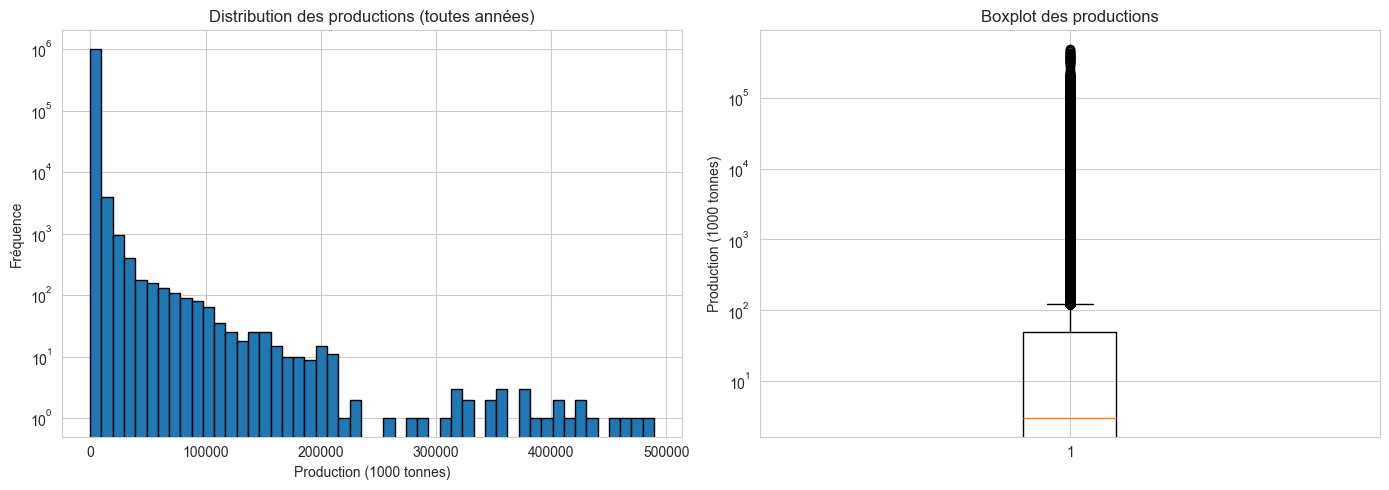

In [14]:
# Visualisation distribution (échantillon)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(all_values_clean, bins=50, edgecolor='black')
axes[0].set_xlabel('Production (1000 tonnes)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des productions (toutes années)')
axes[0].set_yscale('log')

# Boxplot
axes[1].boxplot(all_values_clean, vert=True)
axes[1].set_ylabel('Production (1000 tonnes)')
axes[1].set_title('Boxplot des productions')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### 2.5 Outliers

In [15]:
# Détection outliers (méthode IQR)
print("=" * 60)
print("⚠️  DÉTECTION D'OUTLIERS (méthode IQR)")
print("=" * 60)

Q1 = np.percentile(all_values_clean, 25)
Q3 = np.percentile(all_values_clean, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (all_values_clean < lower_bound) | (all_values_clean > upper_bound)
outliers_count = outliers.sum()
outliers_pct = (outliers_count / len(all_values_clean)) * 100

print(f"Q1 (25%): {Q1:,.0f}")
print(f"Q3 (75%): {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"\nBorne inférieure: {lower_bound:,.0f}")
print(f"Borne supérieure: {upper_bound:,.0f}")
print(f"\nNombre d'outliers: {outliers_count:,} ({outliers_pct:.2f}%)")

⚠️  DÉTECTION D'OUTLIERS (méthode IQR)
Q1 (25%): 0
Q3 (75%): 49
IQR: 49

Borne inférieure: -74
Borne supérieure: 122

Nombre d'outliers: 178,346 (17.47%)


In [16]:
# Identifier les pays/produits avec les plus fortes productions (outliers potentiels)
print("\n📊 Top 10 des productions les plus élevées:")

# Créer un dataframe avec valeur max par ligne
df_fao['Max_Production'] = df_fao[year_cols].max(axis=1)
top_producers = df_fao.nlargest(10, 'Max_Production')[['Area', 'Item', 'Element', 'Max_Production']]
print(top_producers)


📊 Top 10 des productions les plus élevées:
                           Area                      Item Element  \
4249            China, mainland                Vegetables    Food   
4186            China, mainland         Vegetables, Other    Food   
4237            China, mainland  Cereals - Excluding Beer    Food   
4236            China, mainland  Cereals - Excluding Beer    Feed   
9139                      India  Cereals - Excluding Beer    Food   
20506  United States of America  Cereals - Excluding Beer    Feed   
20399  United States of America        Maize and products    Feed   
4126            China, mainland        Maize and products    Feed   
4250            China, mainland   Fruits - Excluding Wine    Food   
9151                      India                Vegetables    Food   

       Max_Production  
4249         489299.0  
4186         426850.0  
4237         210855.0  
4236         193043.0  
9139         185884.0  
20506        170320.0  
20399        155831.0  
4126

---
## 3. Analyse Food_Production.csv - Impact environnemental

### 3.1 Chargement et inspection

In [17]:
# Chargement
print("⏳ Chargement Food_Production.csv...")
df_impact = pd.read_csv(IMPACT_FILE)
print(f"✅ Chargé: {len(df_impact):,} lignes × {len(df_impact.columns)} colonnes")

# Aperçu
df_impact.head(10)

⏳ Chargement Food_Production.csv...
✅ Chargé: 43 lignes × 23 colonnes


,Food product,Land use change,Animal Feed,Farm,Processing,Transport,Packging,Retail,Total_emissions,Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal),Eutrophying emissions per kilogram (gPO₄eq per kilogram),Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein),Freshwater withdrawals per 1000kcal (liters per 1000kcal),Freshwater withdrawals per 100g protein (liters per 100g protein),Freshwater withdrawals per kilogram (liters per kilogram),Greenhouse gas emissions per 1000kcal (kgCO₂eq per 1000kcal),Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein),Land use per 1000kcal (m² per 1000kcal),Land use per kilogram (m² per kilogram),Land use per 100g protein (m² per 100g protein),Scarcity-weighted water use per kilogram (liters per kilogram),Scarcity-weighted water use per 100g protein (liters per 100g protein),Scarcity-weighted water use per 1000kcal (liters per 1000 kilocalories)
0,Wheat & Rye (Bread),0.1,0.0,0.8,0.2,0.1,0.1,0.1,1.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Maize (Meal),0.3,0.0,0.5,0.1,0.1,0.1,0.0,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Barley (Beer),0.0,0.0,0.2,0.1,0.0,0.5,0.3,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Oatmeal,0.0,0.0,1.4,0.0,0.1,0.1,0.0,1.6,4.281357,11.23,8.638462,183.911552,371.076923,482.4,0.945482,1.907692,2.897446,7.60,5.846154,18786.2,14450.92308,7162.104461
4,Rice,0.0,0.0,3.6,0.1,0.1,0.1,0.1,4.0,9.514379,35.07,49.394366,609.983722,3166.760563,2248.4,1.207271,6.267606,0.759631,2.80,3.943662,49576.3,69825.77465,13449.891480
5,Potatoes,0.0,0.0,0.2,0.0,0.1,0.0,0.0,0.3,4.754098,3.48,20.470588,80.737705,347.647059,59.1,0.628415,2.705882,1.202186,0.88,5.176471,2754.2,16201.17647,3762.568306
6,Cassava,0.6,0.0,0.2,0.0,0.1,0.0,0.0,0.9,0.708419,0.69,7.666667,NaN,NaN,0.0,1.355236,14.666667,1.858316,1.81,20.111111,0.0,NaN,NaN
7,Cane Sugar,1.2,0.0,0.5,0.0,0.8,0.1,0.0,2.6,4.820513,16.92,NaN,176.666667,NaN,620.1,0.911681,NaN,0.581197,2.04,NaN,16438.6,NaN,4683.361823
8,Beet Sugar,0.0,0.0,0.5,0.2,0.6,0.1,0.0,1.4,1.541311,5.41,NaN,62.022792,NaN,217.7,0.515670,NaN,0.521368,1.83,NaN,9493.3,NaN,2704.643875
9,Other Pulses,0.0,0.0,1.1,0.0,0.1,0.4,0.0,1.6,5.008798,17.08,7.977581,NaN,203.503036,435.7,0.524927,0.836058,4.565982,15.57,7.272303,22477.4,10498.55208,NaN


In [18]:
# Informations générales
print("=" * 60)
print("📊 STRUCTURE Food_Production.csv")
print("=" * 60)
print(f"Dimensions: {df_impact.shape[0]} lignes × {df_impact.shape[1]} colonnes")
print(f"\nListe des colonnes:")
for i, col in enumerate(df_impact.columns, 1):
    print(f"  {i:2d}. {col}")

📊 STRUCTURE Food_Production.csv
Dimensions: 43 lignes × 23 colonnes

Liste des colonnes:
   1. Food product
   2. Land use change
   3. Animal Feed
   4. Farm
   5. Processing
   6. Transport
   7. Packging
   8. Retail
   9. Total_emissions
  10. Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal)
  11. Eutrophying emissions per kilogram (gPO₄eq per kilogram)
  12. Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)
  13. Freshwater withdrawals per 1000kcal (liters per 1000kcal)
  14. Freshwater withdrawals per 100g protein (liters per 100g protein)
  15. Freshwater withdrawals per kilogram (liters per kilogram)
  16. Greenhouse gas emissions per 1000kcal (kgCO₂eq per 1000kcal)
  17. Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)
  18. Land use per 1000kcal (m² per 1000kcal)
  19. Land use per kilogram (m² per kilogram)
  20. Land use per 100g protein (m² per 100g protein)
  21. Scarcity-weighted water use per kilogram (liters per kilogram)

In [19]:
# Types et mémoire
print("\n" + "=" * 60)
print("📋 TYPES DE DONNÉES")
print("=" * 60)
print(df_impact.dtypes)

impact_memory = df_impact.memory_usage(deep=True).sum() / 1024
print(f"\n💾 Mémoire totale: {impact_memory:.2f} KB")


📋 TYPES DE DONNÉES
Food product                                                                object
Land use change                                                            float64
Animal Feed                                                                float64
Farm                                                                       float64
Processing                                                                 float64
Transport                                                                  float64
Packging                                                                   float64
Retail                                                                     float64
Total_emissions                                                            float64
Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal)                   float64
Eutrophying emissions per kilogram (gPO₄eq per kilogram)                   float64
Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protei

### 3.2 Qualité des données

In [20]:
# Valeurs manquantes
print("=" * 60)
print("🔍 QUALITÉ DES DONNÉES")
print("=" * 60)

missing_impact = df_impact.isnull().sum()
missing_impact_pct = (missing_impact / len(df_impact)) * 100

print("\nValeurs manquantes par colonne:")
for col in df_impact.columns:
    nulls = missing_impact[col]
    pct = missing_impact_pct[col]
    if nulls > 0:
        print(f"  {col:50s}: {nulls:3d} ({pct:5.1f}%)")

print(f"\nLignes dupliquées: {df_impact.duplicated().sum()}")

🔍 QUALITÉ DES DONNÉES

Valeurs manquantes par colonne:
  Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal):  10 ( 23.3%)
  Eutrophying emissions per kilogram (gPO₄eq per kilogram):   5 ( 11.6%)
  Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein):  16 ( 37.2%)
  Freshwater withdrawals per 1000kcal (liters per 1000kcal):  13 ( 30.2%)
  Freshwater withdrawals per 100g protein (liters per 100g protein):  17 ( 39.5%)
  Freshwater withdrawals per kilogram (liters per kilogram):   5 ( 11.6%)
  Greenhouse gas emissions per 1000kcal (kgCO₂eq per 1000kcal):  10 ( 23.3%)
  Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein):  16 ( 37.2%)
  Land use per 1000kcal (m² per 1000kcal)           :  10 ( 23.3%)
  Land use per kilogram (m² per kilogram)           :   5 ( 11.6%)
  Land use per 100g protein (m² per 100g protein)   :  16 ( 37.2%)
  Scarcity-weighted water use per kilogram (liters per kilogram):   5 ( 11.6%)
  Scarcity-weighted water use per 100g pr

### 3.3 Analyse des métriques d'impact

In [21]:
# Liste des produits
print("=" * 60)
print("🥗 PRODUITS ALIMENTAIRES")
print("=" * 60)
print(f"Nombre de produits: {df_impact['Food product'].nunique()}")
print(f"\nListe complète:")
for i, product in enumerate(df_impact['Food product'].values, 1):
    print(f"  {i:2d}. {product}")

🥗 PRODUITS ALIMENTAIRES
Nombre de produits: 43

Liste complète:
   1. Wheat & Rye (Bread)
   2. Maize (Meal)
   3. Barley (Beer)
   4. Oatmeal
   5. Rice
   6. Potatoes
   7. Cassava
   8. Cane Sugar
   9. Beet Sugar
  10. Other Pulses
  11. Peas
  12. Nuts
  13. Groundnuts
  14. Soymilk
  15. Tofu
  16. Soybean Oil
  17. Palm Oil
  18. Sunflower Oil
  19. Rapeseed Oil
  20. Olive Oil
  21. Tomatoes
  22. Onions & Leeks
  23. Root Vegetables
  24. Brassicas
  25. Other Vegetables
  26. Citrus Fruit
  27. Bananas
  28. Apples
  29. Berries & Grapes
  30. Wine
  31. Other Fruit
  32. Coffee
  33. Dark Chocolate
  34. Beef (beef herd)
  35. Beef (dairy herd)
  36. Lamb & Mutton
  37. Pig Meat
  38. Poultry Meat
  39. Milk
  40. Cheese
  41. Eggs
  42. Fish (farmed)
  43. Shrimps (farmed)


In [22]:
# Colonnes d'impact disponibles
print("\n" + "=" * 60)
print("🌍 MÉTRIQUES D'IMPACT ENVIRONNEMENTAL")
print("=" * 60)

impact_cols = [
    'Total_emissions',  # GES total
    'Greenhouse gas emissions per kilogram (kgCO₂eq per kilogram)',
    'Freshwater withdrawals per kilogram (liters per kilogram)',
    'Land use per kilogram (m² per kilogram)',
    'Eutrophying emissions per kilogram (gPO₄eq per kilogram)'
]

# Vérifier disponibilité
for col in impact_cols:
    if col in df_impact.columns:
        non_null = df_impact[col].notna().sum()
        print(f"✅ {col:60s}: {non_null} valeurs")
    else:
        print(f"❌ {col:60s}: NON DISPONIBLE")


🌍 MÉTRIQUES D'IMPACT ENVIRONNEMENTAL
✅ Total_emissions                                             : 43 valeurs
❌ Greenhouse gas emissions per kilogram (kgCO₂eq per kilogram): NON DISPONIBLE
✅ Freshwater withdrawals per kilogram (liters per kilogram)   : 38 valeurs
✅ Land use per kilogram (m² per kilogram)                     : 38 valeurs
✅ Eutrophying emissions per kilogram (gPO₄eq per kilogram)    : 38 valeurs


In [23]:
# Statistiques descriptives des impacts
print("\n📊 Statistiques descriptives (Total_emissions - kgCO₂eq):")
print(df_impact['Total_emissions'].describe())

# Top/Bottom produits par émission
print("\n🔝 Top 5 produits avec le plus d'émissions CO₂:")
print(df_impact.nlargest(5, 'Total_emissions')[['Food product', 'Total_emissions']])

print("\n✅ Top 5 produits avec le moins d'émissions CO₂:")
print(df_impact.nsmallest(5, 'Total_emissions')[['Food product', 'Total_emissions']])


📊 Statistiques descriptives (Total_emissions - kgCO₂eq):
count    43.000000
mean      5.972093
std      10.501753
min       0.200000
25%       0.850000
50%       1.600000
75%       6.000000
max      59.600000
Name: Total_emissions, dtype: float64

🔝 Top 5 produits avec le plus d'émissions CO₂:
         Food product  Total_emissions
33   Beef (beef herd)             59.6
35      Lamb & Mutton             24.5
39             Cheese             21.2
34  Beef (dairy herd)             21.1
32     Dark Chocolate             18.7

✅ Top 5 produits avec le moins d'émissions CO₂:
       Food product  Total_emissions
11             Nuts              0.2
5          Potatoes              0.3
21   Onions & Leeks              0.3
22  Root Vegetables              0.3
25     Citrus Fruit              0.3


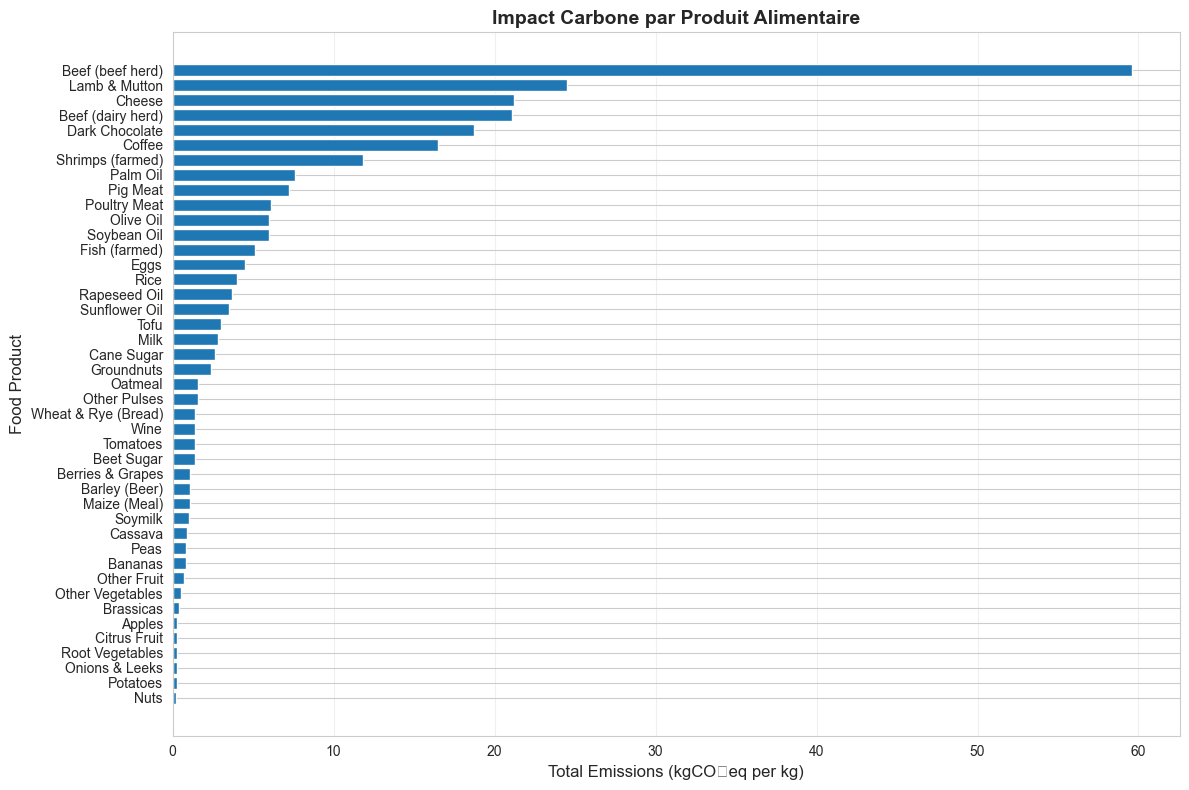

In [24]:
# Visualisation impact par produit
fig, ax = plt.subplots(figsize=(12, 8))

# Trier par émissions
df_sorted = df_impact.sort_values('Total_emissions', ascending=True)

ax.barh(df_sorted['Food product'], df_sorted['Total_emissions'])
ax.set_xlabel('Total Emissions (kgCO₂eq per kg)', fontsize=12)
ax.set_ylabel('Food Product', fontsize=12)
ax.set_title('Impact Carbone par Produit Alimentaire', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Mapping des produits FAO ↔ Impact

**Objectif**: Identifier la correspondance entre les noms de produits dans FAO.csv et Food_Production.csv

In [25]:
# Liste des produits FAO
print("=" * 60)
print("🔗 MAPPING PRODUITS FAO ↔ IMPACT")
print("=" * 60)

fao_products = df_fao['Item'].unique()
impact_products = df_impact['Food product'].unique()

print(f"Produits FAO: {len(fao_products)}")
print(f"Produits Impact: {len(impact_products)}")

print("\n📋 Échantillon produits FAO (20 premiers):")
for i, prod in enumerate(sorted(fao_products)[:20], 1):
    print(f"  {i:2d}. {prod}")

🔗 MAPPING PRODUITS FAO ↔ IMPACT
Produits FAO: 115
Produits Impact: 43

📋 Échantillon produits FAO (20 premiers):
   1. Alcoholic Beverages
   2. Animal fats
   3. Apples and products
   4. Aquatic Animals, Others
   5. Aquatic Plants
   6. Aquatic Products, Other
   7. Bananas
   8. Barley and products
   9. Beans
  10. Beer
  11. Beverages, Alcoholic
  12. Beverages, Fermented
  13. Bovine Meat
  14. Butter, Ghee
  15. Cassava and products
  16. Cephalopods
  17. Cereals - Excluding Beer
  18. Cereals, Other
  19. Citrus, Other
  20. Cloves


In [26]:
# Recherche de correspondances (matching simple par mots-clés)
print("\n🔍 Recherche de correspondances automatiques...\n")

# Mapping manuel à affiner
mapping_dict = {
    'Wheat': ['Wheat', 'Wheat & Rye'],
    'Rice': ['Rice', 'Rice (Milled Equivalent)'],
    'Barley': ['Barley', 'Barley and products'],
    'Maize': ['Maize', 'Maize (Meal)'],
    'Oats': ['Oatmeal'],
    'Potatoes': ['Potatoes'],
    'Sugar': ['Cane Sugar', 'Beet Sugar'],
    'Soybeans': ['Soybean Oil', 'Soymilk', 'Tofu'],
    'Groundnuts': ['Groundnuts'],
    'Palm': ['Palm Oil'],
    'Sunflower': ['Sunflower Oil'],
    'Rapeseed': ['Rapeseed Oil']
}

print("🎯 Correspondances identifiées (à affiner):")
for fao_key, impact_list in mapping_dict.items():
    print(f"\n  FAO: {fao_key}")
    for imp in impact_list:
        print(f"    → Impact: {imp}")


🔍 Recherche de correspondances automatiques...

🎯 Correspondances identifiées (à affiner):

  FAO: Wheat
    → Impact: Wheat
    → Impact: Wheat & Rye

  FAO: Rice
    → Impact: Rice
    → Impact: Rice (Milled Equivalent)

  FAO: Barley
    → Impact: Barley
    → Impact: Barley and products

  FAO: Maize
    → Impact: Maize
    → Impact: Maize (Meal)

  FAO: Oats
    → Impact: Oatmeal

  FAO: Potatoes
    → Impact: Potatoes

  FAO: Sugar
    → Impact: Cane Sugar
    → Impact: Beet Sugar

  FAO: Soybeans
    → Impact: Soybean Oil
    → Impact: Soymilk
    → Impact: Tofu

  FAO: Groundnuts
    → Impact: Groundnuts

  FAO: Palm
    → Impact: Palm Oil

  FAO: Sunflower
    → Impact: Sunflower Oil

  FAO: Rapeseed
    → Impact: Rapeseed Oil


In [27]:
# Créer une table de correspondance à affiner manuellement
print("\n⚠️  ACTIONS NÉCESSAIRES:")
print("""
1. Créer une table de correspondance manuelle FAO ↔ Impact
2. Certains produits FAO n'ont pas d'équivalent dans Impact (ex: produits transformés)
3. Certains produits Impact sont des catégories (ex: "Wheat & Rye")
4. Solution: Créer un fichier CSV de mapping dans data/raw/product_mapping.csv

Colonnes suggérées:
  - fao_item: Nom dans FAO.csv
  - impact_product: Nom dans Food_Production.csv
  - category: Catégorie (céréales, viande, légumes, etc.)
  - match_quality: exact, approximate, missing
""")


⚠️  ACTIONS NÉCESSAIRES:

1. Créer une table de correspondance manuelle FAO ↔ Impact
2. Certains produits FAO n'ont pas d'équivalent dans Impact (ex: produits transformés)
3. Certains produits Impact sont des catégories (ex: "Wheat & Rye")
4. Solution: Créer un fichier CSV de mapping dans data/raw/product_mapping.csv

Colonnes suggérées:
  - fao_item: Nom dans FAO.csv
  - impact_product: Nom dans Food_Production.csv
  - category: Catégorie (céréales, viande, légumes, etc.)
  - match_quality: exact, approximate, missing



---
## 5. Architecture Base de Données

### 5.1 Système OLAP vs OLTP

In [28]:
print("=" * 60)
print("🏗️  ARCHITECTURE BASE DE DONNÉES")
print("=" * 60)

print("""
📊 SYSTÈME RECOMMANDÉ: OLAP (Online Analytical Processing)

Justification:
- Données historiques (1961-2023) = lecture seule
- Analyses multidimensionnelles (pays × produit × année)
- Agrégations complexes (SUM, AVG par dimensions)
- Pas de transactions fréquentes (OLTP)

Modèle: Schéma en étoile (Star Schema)
""")

🏗️  ARCHITECTURE BASE DE DONNÉES

📊 SYSTÈME RECOMMANDÉ: OLAP (Online Analytical Processing)

Justification:
- Données historiques (1961-2023) = lecture seule
- Analyses multidimensionnelles (pays × produit × année)
- Agrégations complexes (SUM, AVG par dimensions)
- Pas de transactions fréquentes (OLTP)

Modèle: Schéma en étoile (Star Schema)



### 5.2 Tables de Fait et Dimensions

In [29]:
print("\n📐 SCHÉMA PROPOSÉ (Star Schema)\n")

schema = """
┌─────────────────────────────────────────────────────┐
│           TABLES DE FAIT (Fact Tables)             │
└─────────────────────────────────────────────────────┘

1. Fait_Production
   ├── production_id (PK)
   ├── pays_id (FK → Dim_Pays)
   ├── produit_id (FK → Dim_Produits)
   ├── annee_id (FK → Dim_Temps)
   ├── element (Food/Feed)
   └── quantite_tonnes (NUMERIC)

2. Fait_Impact
   ├── impact_id (PK)
   ├── produit_id (FK → Dim_Produits)
   ├── co2_per_kg (NUMERIC)
   ├── eau_litres_per_kg (NUMERIC)
   ├── land_m2_per_kg (NUMERIC)
   ├── eutrophication_per_kg (NUMERIC)
   └── ... (autres métriques)

┌─────────────────────────────────────────────────────┐
│        TABLES DE DIMENSION (Dimension Tables)      │
└─────────────────────────────────────────────────────┘

3. Dim_Pays
   ├── pays_id (PK)
   ├── nom_pays (VARCHAR)
   ├── code_iso (VARCHAR)
   ├── region (VARCHAR)
   ├── latitude (NUMERIC)
   └── longitude (NUMERIC)

4. Dim_Produits
   ├── produit_id (PK)
   ├── nom_produit (VARCHAR)
   ├── categorie (VARCHAR) [céréales, viande, légumes...]
   └── sous_categorie (VARCHAR)

5. Dim_Temps
   ├── annee_id (PK)
   ├── annee (INTEGER)
   ├── decennie (INTEGER)
   └── periode (VARCHAR) [1960s, 1970s...]

6. Dim_Socio_Economique (enrichissement)
   ├── socio_id (PK)
   ├── pays_id (FK → Dim_Pays)
   ├── annee_id (FK → Dim_Temps)
   ├── pib_per_capita (NUMERIC)
   ├── taux_urbanisation (NUMERIC)
   └── population (NUMERIC)
"""

print(schema)


📐 SCHÉMA PROPOSÉ (Star Schema)


┌─────────────────────────────────────────────────────┐
│           TABLES DE FAIT (Fact Tables)             │
└─────────────────────────────────────────────────────┘

1. Fait_Production
   ├── production_id (PK)
   ├── pays_id (FK → Dim_Pays)
   ├── produit_id (FK → Dim_Produits)
   ├── annee_id (FK → Dim_Temps)
   ├── element (Food/Feed)
   └── quantite_tonnes (NUMERIC)

2. Fait_Impact
   ├── impact_id (PK)
   ├── produit_id (FK → Dim_Produits)
   ├── co2_per_kg (NUMERIC)
   ├── eau_litres_per_kg (NUMERIC)
   ├── land_m2_per_kg (NUMERIC)
   ├── eutrophication_per_kg (NUMERIC)
   └── ... (autres métriques)

┌─────────────────────────────────────────────────────┐
│        TABLES DE DIMENSION (Dimension Tables)      │
└─────────────────────────────────────────────────────┘

3. Dim_Pays
   ├── pays_id (PK)
   ├── nom_pays (VARCHAR)
   ├── code_iso (VARCHAR)
   ├── region (VARCHAR)
   ├── latitude (NUMERIC)
   └── longitude (NUMERIC)

4. Dim_Produits
   ├

### 5.3 Granularité des données

In [30]:
print("\n📏 GRANULARITÉ DES DONNÉES\n")

# Vérifier si df_fao existe
if 'df_fao' in locals():
    # Identifier les colonnes d'années
    year_cols = [col for col in df_fao.columns if col.startswith('Y')]
    
    print("Fait_Production:")
    print("  - Niveau: Pays × Produit × Année × Element")
    print(f"  - Pays uniques: {df_fao['Area'].nunique()}")
    print(f"  - Produits uniques: {df_fao['Item'].nunique()}")
    print(f"  - Années: {len(year_cols)} (1961-2013)")
    print(f"  - Elements: {df_fao['Element'].nunique()}")
else:
    print("⚠️  Veuillez d'abord exécuter les cellules de chargement FAO")

print("\nFait_Impact:")
if 'df_impact' in locals():
    print("  - Niveau: Produit (statique, pas de dimension temporelle)")
    print(f"  - Produits uniques: {df_impact['Food product'].nunique()}")
else:
    print("⚠️  Veuillez d'abord exécuter les cellules de chargement Food_Production")


📏 GRANULARITÉ DES DONNÉES

Fait_Production:
  - Niveau: Pays × Produit × Année × Element
  - Pays uniques: 174
  - Produits uniques: 115
  - Années: 53 (1961-2013)
  - Elements: 2

Fait_Impact:
  - Niveau: Produit (statique, pas de dimension temporelle)
  - Produits uniques: 43


---
## 6. Variable Cible et ML

### 6.1 Définition de la variable cible

In [31]:
print("=" * 60)
print("🎯 VARIABLE CIBLE")
print("=" * 60)

print("""
Variable cible proposée:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 Empreinte Carbone Totale par Pays/Année

Formule:
  Impact_CO2_total = Σ (production_tonnes × 1000 × co2_per_kg)
  
Où:
  - production_tonnes: Production FAO en milliers de tonnes
  - co2_per_kg: Émissions CO₂ par kg (Food_Production.csv)
  - ×1000: Conversion milliers de tonnes → kg

Exemple:
  France 2010, Blé:
  - Production: 38,000 (milliers de tonnes) = 38,000,000 kg
  - Impact blé: 1.4 kgCO₂eq/kg
  → Impact total blé: 38,000,000 × 1.4 = 53,200,000 kgCO₂eq

Unité finale: kgCO₂eq ou tonnes CO₂eq

Type de variable: Continue (régression)
""")

🎯 VARIABLE CIBLE

Variable cible proposée:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 Empreinte Carbone Totale par Pays/Année

Formule:
  Impact_CO2_total = Σ (production_tonnes × 1000 × co2_per_kg)

Où:
  - production_tonnes: Production FAO en milliers de tonnes
  - co2_per_kg: Émissions CO₂ par kg (Food_Production.csv)
  - ×1000: Conversion milliers de tonnes → kg

Exemple:
  France 2010, Blé:
  - Production: 38,000 (milliers de tonnes) = 38,000,000 kg
  - Impact blé: 1.4 kgCO₂eq/kg
  → Impact total blé: 38,000,000 × 1.4 = 53,200,000 kgCO₂eq

Unité finale: kgCO₂eq ou tonnes CO₂eq

Type de variable: Continue (régression)



### 6.2 Type de problématique ML

In [32]:
print("\n" + "=" * 60)
print("🤖 PROBLÉMATIQUES MACHINE LEARNING")
print("=" * 60)

print("""
Problématique 1: RÉGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Objectif: Prédire l'empreinte carbone d'un pays selon son mix alimentaire

Variable cible:
  - Impact_CO2_total (continu)
  
Features (variables explicatives):
  - Production par catégorie (céréales, viande, légumes...)
  - PIB par habitant
  - Taux d'urbanisation
  - Population
  - Année (tendance temporelle)
  
Modèles pressentis:
  1. Régression Linéaire (baseline)
  2. Random Forest Regressor
  3. XGBoost Regressor ⭐ (recommandé)
  4. Ridge/Lasso (si multicolinéarité)

Métriques d'évaluation:
  - R² (coefficient de détermination)
  - RMSE (Root Mean Squared Error)
  - MAE (Mean Absolute Error)
  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Problématique 2: CLUSTERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Objectif: Profiler les pays selon leur régime alimentaire et impact

Features:
  - % production céréales / viande / légumes
  - Impact CO₂ moyen
  - Impact hydrique moyen
  - PIB, urbanisation
  
Modèles pressentis:
  1. KMeans (k=3-7 clusters)
  2. DBSCAN (détection clusters de densité)
  3. Hierarchical Clustering

Métriques d'évaluation:
  - Silhouette Score
  - Davies-Bouldin Index
  - Inertia (KMeans)
  
Visualisation:
  - PCA 2D/3D pour visualiser les clusters
  - Profils moyens par cluster
""")


🤖 PROBLÉMATIQUES MACHINE LEARNING

Problématique 1: RÉGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Objectif: Prédire l'empreinte carbone d'un pays selon son mix alimentaire

Variable cible:
  - Impact_CO2_total (continu)

Features (variables explicatives):
  - Production par catégorie (céréales, viande, légumes...)
  - PIB par habitant
  - Taux d'urbanisation
  - Population
  - Année (tendance temporelle)

Modèles pressentis:
  1. Régression Linéaire (baseline)
  2. Random Forest Regressor
  3. XGBoost Regressor ⭐ (recommandé)
  4. Ridge/Lasso (si multicolinéarité)

Métriques d'évaluation:
  - R² (coefficient de détermination)
  - RMSE (Root Mean Squared Error)
  - MAE (Mean Absolute Error)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Problématique 2: CLUSTERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Objectif: Profiler les pays selon leur régime alimentaire et impact

Features:
  - % production céréales / viande / légumes
  - Impact CO₂ moyen
  - Impact hydrique moyen
  - PIB, urbani

### 6.3 Réalisabilité de la problématique

In [33]:
print("\n" + "=" * 60)
print("✅ RÉALISABILITÉ")
print("=" * 60)

print("""
La problématique EST réalisable car:

✅ Données disponibles:
   - Production mondiale détaillée (FAO)
   - Impact environnemental par produit (Food_Production)
   - Possibilité d'enrichir (World Bank, OWID)

✅ Variable cible claire:
   - Calculable: production × impact = empreinte
   - Continue (régression)
   - Interprétable

✅ Features pertinentes:
   - Production par catégorie
   - Indicateurs socio-économiques
   - Dimension temporelle

✅ Volume de données suffisant:
   - FAO: ~100K lignes (pays × produits × années)
   - Après transformation: ~250K observations
   - Suffisant pour ML

⚠️  Défis identifiés:
   1. Mapping FAO ↔ Impact à finaliser
   2. Données FAO s'arrêtent en 2013 (enrichir 2014-2023)
   3. Valeurs manquantes à gérer (imputation)
   4. Outliers (grandes productions) à traiter
""")


✅ RÉALISABILITÉ

La problématique EST réalisable car:

✅ Données disponibles:
   - Production mondiale détaillée (FAO)
   - Impact environnemental par produit (Food_Production)
   - Possibilité d'enrichir (World Bank, OWID)

✅ Variable cible claire:
   - Calculable: production × impact = empreinte
   - Continue (régression)
   - Interprétable

✅ Features pertinentes:
   - Production par catégorie
   - Indicateurs socio-économiques
   - Dimension temporelle

✅ Volume de données suffisant:
   - FAO: ~100K lignes (pays × produits × années)
   - Après transformation: ~250K observations
   - Suffisant pour ML

⚠️  Défis identifiés:
   1. Mapping FAO ↔ Impact à finaliser
   2. Données FAO s'arrêtent en 2013 (enrichir 2014-2023)
   3. Valeurs manquantes à gérer (imputation)
   4. Outliers (grandes productions) à traiter



---
## 7. Conclusions et prochaines étapes

### 7.1 Synthèse de l'exploration

In [34]:
print("=" * 60)
print("📝 SYNTHÈSE DE L'EXPLORATION NAÏVE")
print("=" * 60)

# Calculer les statistiques si les variables n'existent pas
if 'df_fao' in locals():
    # Recalculer si nécessaire
    if 'year_cols' not in locals():
        year_cols = [col for col in df_fao.columns if col.startswith('Y')]
    if 'total_mb' not in locals():
        total_mb = df_fao.memory_usage(deep=True).sum() / 1024**2
    if 'duplicates' not in locals():
        duplicates = df_fao.duplicated().sum()
    if 'outliers_pct' not in locals():
        all_values = df_fao[year_cols].values.flatten()
        all_values_clean = all_values[~np.isnan(all_values)]
        Q1 = np.percentile(all_values_clean, 25)
        Q3 = np.percentile(all_values_clean, 75)
        IQR = Q3 - Q1
        outliers = (all_values_clean < Q1 - 1.5 * IQR) | (all_values_clean > Q3 + 1.5 * IQR)
        outliers_pct = (outliers.sum() / len(all_values_clean)) * 100
    
    print(f"""
1. FAO.csv - Production mondiale
   ├── Lignes: {len(df_fao):,}
   ├── Colonnes: {len(df_fao.columns)}
   ├── Pays: {df_fao['Area'].nunique()}
   ├── Produits: {df_fao['Item'].nunique()}
   ├── Période: 1961-2013 ({len(year_cols)} années)
   ├── Mémoire: {total_mb:.2f} MB
   ├── Duplicatas: {duplicates:,}
   └── Outliers: {outliers_pct:.1f}%
""")
else:
    print("\n⚠️  FAO.csv non chargé - Exécutez d'abord la section 2\n")

if 'df_impact' in locals():
    if 'impact_memory' not in locals():
        impact_memory = df_impact.memory_usage(deep=True).sum() / 1024
    
    print(f"""
2. Food_Production.csv - Impact environnemental
   ├── Lignes: {len(df_impact)}
   ├── Colonnes: {len(df_impact.columns)}
   ├── Produits: {df_impact['Food product'].nunique()}
   ├── Métriques: CO₂, eau, terres, eutrophisation
   └── Qualité: Valeurs manquantes à gérer
""")
else:
    print("⚠️  Food_Production.csv non chargé - Exécutez d'abord la section 3\n")

print("""
3. Architecture recommandée
   ├── Système: OLAP (analyse multidimensionnelle)
   ├── Modèle: Schéma en étoile
   ├── Tables de fait: Production, Impact
   └── Dimensions: Pays, Produits, Temps, Socio-économique

4. Machine Learning
   ├── Régression: Prédire empreinte carbone
   │   └── Modèles: RandomForest, XGBoost, Ridge
   └── Clustering: Profiler pays
       └── Modèles: KMeans, DBSCAN
""")

📝 SYNTHÈSE DE L'EXPLORATION NAÏVE

1. FAO.csv - Production mondiale
   ├── Lignes: 21,477
   ├── Colonnes: 64
   ├── Pays: 174
   ├── Produits: 115
   ├── Période: 1961-2013 (53 années)
   ├── Mémoire: 15.39 MB
   ├── Duplicatas: 0
   └── Outliers: 17.5%


2. Food_Production.csv - Impact environnemental
   ├── Lignes: 43
   ├── Colonnes: 23
   ├── Produits: 43
   ├── Métriques: CO₂, eau, terres, eutrophisation
   └── Qualité: Valeurs manquantes à gérer


3. Architecture recommandée
   ├── Système: OLAP (analyse multidimensionnelle)
   ├── Modèle: Schéma en étoile
   ├── Tables de fait: Production, Impact
   └── Dimensions: Pays, Produits, Temps, Socio-économique

4. Machine Learning
   ├── Régression: Prédire empreinte carbone
   │   └── Modèles: RandomForest, XGBoost, Ridge
   └── Clustering: Profiler pays
       └── Modèles: KMeans, DBSCAN



### 7.2 Actions à entreprendre

In [35]:
print("\n" + "=" * 60)
print("🚀 PROCHAINES ÉTAPES")
print("=" * 60)

print("""
Phase 1: Enrichissement données (2-3h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Créer notebook enrichissement_donnees.ipynb
□ Récupérer production FAO 2014-2022 (API FAOSTAT)
□ Récupérer PIB, urbanisation (World Bank API)
□ Récupérer consommation viande (OWID GitHub)
□ Créer table de mapping produits FAO ↔ Impact

Phase 2: Architecture DB (1h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Modéliser schéma sur DBDiagram.io
□ Créer Data Lake (DuckDB/PostgreSQL)
□ Définir tables DWH (fait + dimensions)

Phase 3: Pipeline ETL (4h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Notebook 02_etl_pipeline.ipynb
□ Unpivot données FAO (années en lignes)
□ Jointure Production × Impact
□ Calcul empreinte carbone totale
□ Gestion nulls, outliers
□ Ingestion vers DWH
□ Export script etl_pipeline.py

Phase 4: EDA approfondie (8h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Notebook 03_eda_avancee.ipynb
□ Analyses uni/bi/multi-variées
□ Tests statistiques (ANOVA, corrélations)
□ Visualisations avancées
□ Conclusion: features pour ML

Phase 5: Machine Learning (6h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Notebook 04_machine_learning.ipynb
□ Preprocessing (split, encoding, scaling)
□ Régression (RandomForest, XGBoost)
□ Clustering (KMeans, DBSCAN)
□ Fine-tuning, MLFlow tracking
□ Sauvegarde modèles (.pkl)

Phase 6: Application Streamlit (6h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Créer app/streamlit_app.py
□ Simulateur menu
□ Comparateur pays
□ Prédictions
□ Déploiement
""")


🚀 PROCHAINES ÉTAPES

Phase 1: Enrichissement données (2-3h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Créer notebook enrichissement_donnees.ipynb
□ Récupérer production FAO 2014-2022 (API FAOSTAT)
□ Récupérer PIB, urbanisation (World Bank API)
□ Récupérer consommation viande (OWID GitHub)
□ Créer table de mapping produits FAO ↔ Impact

Phase 2: Architecture DB (1h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Modéliser schéma sur DBDiagram.io
□ Créer Data Lake (DuckDB/PostgreSQL)
□ Définir tables DWH (fait + dimensions)

Phase 3: Pipeline ETL (4h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Notebook 02_etl_pipeline.ipynb
□ Unpivot données FAO (années en lignes)
□ Jointure Production × Impact
□ Calcul empreinte carbone totale
□ Gestion nulls, outliers
□ Ingestion vers DWH
□ Export script etl_pipeline.py

Phase 4: EDA approfondie (8h)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
□ Notebook 03_eda_avancee.ipynb
□ Analyses uni/bi/multi-variées
□ Tests statistiques (ANOVA, corrélations)
□ Visualisations ava

### 7.3 Sauvegarde des résultats

In [36]:
# Sauvegarder les statistiques clés
import json
from pathlib import Path

summary = {}

# Statistiques FAO
if 'df_fao' in locals():
    # Recalculer les variables si nécessaire
    if 'year_cols' not in locals():
        year_cols = [col for col in df_fao.columns if col.startswith('Y')]
    if 'total_mb' not in locals():
        total_mb = df_fao.memory_usage(deep=True).sum() / 1024**2
    if 'duplicates' not in locals():
        duplicates = df_fao.duplicated().sum()
    if 'outliers_pct' not in locals():
        all_values = df_fao[year_cols].values.flatten()
        all_values_clean = all_values[~np.isnan(all_values)]
        Q1 = np.percentile(all_values_clean, 25)
        Q3 = np.percentile(all_values_clean, 75)
        IQR = Q3 - Q1
        outliers = (all_values_clean < Q1 - 1.5 * IQR) | (all_values_clean > Q3 + 1.5 * IQR)
        outliers_pct = (outliers.sum() / len(all_values_clean)) * 100
    
    summary['fao'] = {
        'rows': len(df_fao),
        'columns': len(df_fao.columns),
        'countries': df_fao['Area'].nunique(),
        'products': df_fao['Item'].nunique(),
        'years': len(year_cols),
        'memory_mb': float(total_mb),
        'duplicates': int(duplicates),
        'outliers_pct': float(outliers_pct)
    }
    print("✅ Statistiques FAO calculées")
else:
    print("⚠️  FAO.csv non chargé - Statistiques FAO non disponibles")

# Statistiques Impact
if 'df_impact' in locals():
    if 'impact_memory' not in locals():
        impact_memory = df_impact.memory_usage(deep=True).sum() / 1024
    
    summary['impact'] = {
        'rows': len(df_impact),
        'columns': len(df_impact.columns),
        'products': df_impact['Food product'].nunique(),
        'memory_kb': float(impact_memory)
    }
    print("✅ Statistiques Impact calculées")
else:
    print("⚠️  Food_Production.csv non chargé - Statistiques Impact non disponibles")

# Sauvegarder en JSON
if summary:
    output_path = Path('../docs/exploration_summary.json')
    output_path.parent.mkdir(exist_ok=True)
    
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    
    print(f"\n✅ Résumé sauvegardé: {output_path}")
    print(f"📊 Contenu: {list(summary.keys())}")
else:
    print("\n⚠️  Aucune donnée à sauvegarder - Exécutez d'abord les sections 2 et 3")

✅ Statistiques FAO calculées
✅ Statistiques Impact calculées

✅ Résumé sauvegardé: ..\docs\exploration_summary.json
📊 Contenu: ['fao', 'impact']
